<a href="https://colab.research.google.com/github/Aswin-2002/Synthetic-Brain-MRI-Generation-using-Diffusion-model-DDPM-for-alzheimer/blob/main/coronal-CNN-classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Safe remount — always run this first
import os, shutil, subprocess
from google.colab import drive

subprocess.run(['fusermount', '-uz', '/content/drive'], capture_output=True)
shutil.rmtree('/content/drive', ignore_errors=True)
os.makedirs('/content/drive', exist_ok=True)

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Cell 1: Install and mount ─────────────────────────────
!pip install torch torchvision scikit-learn -q

from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# ── Cell 2: Imports ────────────────────────────────────────
import os
import re
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [ ]:
# ── Cell 3: Config ─────────────────────────────────────────
HEALTHY_DIR    = '/content/drive/MyDrive/coronal-healthy'
ALZ_REAL_DIR   = '/content/drive/MyDrive/oasis-coronal-alzheimers'
ALZ_SYNTH_DIR = '/content/drive/MyDrive/ddpm_coronal_output/fid_generated'  # 350 DDPM synthetic images

IMAGE_SIZE  = 128
BATCH_SIZE  = 16
NUM_EPOCHS  = 20
LEARNING_RATE = 1e-4
TEST_SPLIT  = 0.2
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

In [ ]:
# ── Cell 4: Extract subject ID from filename ───────────────
def get_subject_id(filename):
    # Matches pattern like OAS1_0003_MR1
    match = re.match(r'(OAS1_\d+_MR\d+)', filename)
    return match.group(1) if match else None

# Quick test
test_name = os.listdir(HEALTHY_DIR)[0]
print(f"Example filename: {test_name}")
print(f"Extracted subject ID: {get_subject_id(test_name)}")

Example filename: OAS1_0258_MR1_coronal_anterior_hippocampal_idx098.png
Extracted subject ID: OAS1_0258_MR1


In [ ]:
# ── Cell 5: Subject-level train/test split ──────────────────
def split_by_subject(directory, test_size=0.2, seed=42):
    files = [f for f in os.listdir(directory) if f.endswith('.png')]

    # Group files by subject
    subject_files = {}
    for f in files:
        sid = get_subject_id(f)
        subject_files.setdefault(sid, []).append(f)

    subjects = list(subject_files.keys())
    train_subjects, test_subjects = train_test_split(
        subjects, test_size=test_size, random_state=seed
    )

    train_files = [f for s in train_subjects for f in subject_files[s]]
    test_files  = [f for s in test_subjects  for f in subject_files[s]]

    return train_files, test_files

# Split healthy and real Alzheimer's by subject
healthy_train, healthy_test = split_by_subject(HEALTHY_DIR, TEST_SPLIT, RANDOM_SEED)
alz_train, alz_test         = split_by_subject(ALZ_REAL_DIR, TEST_SPLIT, RANDOM_SEED)

print(f"Healthy   — train: {len(healthy_train)}, test: {len(healthy_test)}")
print(f"Alzheimer — train: {len(alz_train)}, test: {len(alz_test)}")

# Synthetic images have no real subject — use ALL of them only in training, NEVER in test
synth_files = [f for f in os.listdir(ALZ_SYNTH_DIR) if f.endswith('.png')]
print(f"Synthetic — available for training: {len(synth_files)}")

Healthy   — train: 1876, test: 476
Alzheimer — train: 560, test: 140
Synthetic — available for training: 350


In [ ]:
# ── Cell 6: Dataset class ───────────────────────────────────
class MRIClassifierDataset(Dataset):
    def __init__(self, healthy_files, healthy_dir,
                 alz_files, alz_dir, transform=None):
        self.samples = []
        for f in healthy_files:
            self.samples.append((os.path.join(healthy_dir, f), 0))  # 0 = healthy
        for f in alz_files:
            self.samples.append((os.path.join(alz_dir, f), 1))      # 1 = alzheimers
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('L')
        if self.transform:
            img = self.transform(img)
        return img, label

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

# ── TEST SET — always real data only, same for all 3 experiments ──
test_dataset = MRIClassifierDataset(
    healthy_test, HEALTHY_DIR,
    alz_test, ALZ_REAL_DIR,
    transform=transform
)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Test set size: {len(test_dataset)}")

Test set size: 616


In [ ]:
# ── Cell 7: Three training configurations ───────────────────

# Config A — Real only
dataset_A = MRIClassifierDataset(
    healthy_train, HEALTHY_DIR,
    alz_train, ALZ_REAL_DIR,
    transform=transform
)

# Config B — Real + Synthetic combined
class CombinedDataset(Dataset):
    def __init__(self, healthy_files, healthy_dir,
                 alz_real_files, alz_real_dir,
                 alz_synth_files, alz_synth_dir, transform=None):
        self.samples = []
        for f in healthy_files:
            self.samples.append((os.path.join(healthy_dir, f), 0))
        for f in alz_real_files:
            self.samples.append((os.path.join(alz_real_dir, f), 1))
        for f in alz_synth_files:
            self.samples.append((os.path.join(alz_synth_dir, f), 1))
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('L')
        if self.transform:
            img = self.transform(img)
        return img, label

dataset_B = CombinedDataset(
    healthy_train, HEALTHY_DIR,
    alz_train, ALZ_REAL_DIR,
    synth_files, ALZ_SYNTH_DIR,
    transform=transform
)

# Config C — Healthy + Synthetic only (no real Alzheimer's in training)
dataset_C = MRIClassifierDataset(
    healthy_train, HEALTHY_DIR,
    synth_files, ALZ_SYNTH_DIR,
    transform=transform
)

print(f"Config A (Real only):        {len(dataset_A)} images")
print(f"Config B (Real + Synthetic): {len(dataset_B)} images")
print(f"Config C (Synthetic only):   {len(dataset_C)} images")

Config A (Real only):        2436 images
Config B (Real + Synthetic): 2786 images
Config C (Synthetic only):   2226 images


In [ ]:
# ── Cell 8: Simple CNN model ─────────────────────────────────
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

In [ ]:
# ── Cell 9: Training function ────────────────────────────────
#def train_classifier(train_dataset, name, num_epochs=NUM_EPOCHS):
#    print(f"\n{'='*50}")
#    print(f"Training: {name}")
#    print(f"{'='*50}")
#
#    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
#
#    model = SimpleCNN().to(device)
#    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
#    criterion = nn.CrossEntropyLoss()
#
#    for epoch in range(num_epochs):
#        model.train()
#        epoch_loss = 0
#        for images, labels in train_loader:
#            images, labels = images.to(device), labels.to(device)
#
#            optimizer.zero_grad()
#            outputs = model(images)
#            loss = criterion(outputs, labels)
#            loss.backward()
#            optimizer.step()
#            epoch_loss += loss.item()
#
#        if (epoch+1) % 5 == 0:
#           print(f"  Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss/len(train_loader):.4f}")
#
#    return model
############  REPLACED THE TRAIN CLASSIFIER FN with..
from collections import Counter

def get_class_weights(dataset):
    labels = [label for _, label in dataset.samples]
    counts = Counter(labels)
    total  = len(labels)
    weight_0 = total / (2 * counts[0])
    weight_1 = total / (2 * counts[1])
    return torch.tensor([weight_0, weight_1], dtype=torch.float32).to(device)

def train_classifier(train_dataset, name, num_epochs=NUM_EPOCHS):
    print(f"\n{'='*50}\nTraining: {name}\n{'='*50}")
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    model = SimpleCNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    class_weights = get_class_weights(train_dataset)
    print(f"Class weights — healthy: {class_weights[0]:.3f}, alzheimer: {class_weights[1]:.3f}")
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        if (epoch+1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss/len(train_loader):.4f}")
    return model

def evaluate_classifier(model, test_loader, name):
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec  = recall_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds)
    cm   = confusion_matrix(all_labels, all_preds)

    print(f"\n--- {name} Results ---")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1-score:  {f1:.3f}")
    print(f"Confusion Matrix:\n{cm}")

    return {'name': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'cm': cm}

In [ ]:
# ── Cell 10: Run all three experiments ───────────────────────
results = []

model_A = train_classifier(dataset_A, "Config A: Real Only")
results.append(evaluate_classifier(model_A, test_loader, "Config A: Real Only"))

model_B = train_classifier(dataset_B, "Config B: Real + Synthetic")
results.append(evaluate_classifier(model_B, test_loader, "Config B: Real + Synthetic"))

model_C = train_classifier(dataset_C, "Config C: Synthetic Only")
results.append(evaluate_classifier(model_C, test_loader, "Config C: Synthetic Only"))


Training: Config A: Real Only
Class weights — healthy: 0.649, alzheimer: 2.175
  Epoch 5/20 | Loss: 0.3016
  Epoch 10/20 | Loss: 0.0877
  Epoch 15/20 | Loss: 0.0123
  Epoch 20/20 | Loss: 0.0073

--- Config A: Real Only Results ---
Accuracy:  0.859
Precision: 0.678
Recall:    0.721
F1-score:  0.699
Confusion Matrix:
[[428  48]
 [ 39 101]]

Training: Config B: Real + Synthetic
Class weights — healthy: 0.743, alzheimer: 1.531
  Epoch 5/20 | Loss: 0.2091
  Epoch 10/20 | Loss: 0.0415
  Epoch 15/20 | Loss: 0.0056
  Epoch 20/20 | Loss: 0.0026

--- Config B: Real + Synthetic Results ---
Accuracy:  0.860
Precision: 0.693
Recall:    0.693
F1-score:  0.693
Confusion Matrix:
[[433  43]
 [ 43  97]]

Training: Config C: Synthetic Only
Class weights — healthy: 0.593, alzheimer: 3.180
  Epoch 5/20 | Loss: 0.0025
  Epoch 10/20 | Loss: 0.0000
  Epoch 15/20 | Loss: 0.0005
  Epoch 20/20 | Loss: 0.0000

--- Config C: Synthetic Only Results ---
Accuracy:  0.773
Precision: 0.000
Recall:    0.000
F1-score:  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ── Cell 11: Summary comparison table ────────────────────────
import pandas as pd

summary = pd.DataFrame([
    {'Config': r['name'], 'Accuracy': r['accuracy'], 'Precision': r['precision'],
     'Recall': r['recall'], 'F1': r['f1']}
    for r in results
])
print(summary.to_string(index=False))

summary.to_csv('/content/drive/MyDrive/ddpm_coronal_output/classifier_results.csv', index=False)
print("\n✅ Saved results to Drive")

                    Config  Accuracy  Precision   Recall       F1
       Config A: Real Only  0.858766   0.677852 0.721429 0.698962
Config B: Real + Synthetic  0.860390   0.692857 0.692857 0.692857
  Config C: Synthetic Only  0.772727   0.000000 0.000000 0.000000

✅ Saved results to Drive


Plot saved to: /content/drive/MyDrive/ddpm_coronal_output/synthetic_samples_preview.png


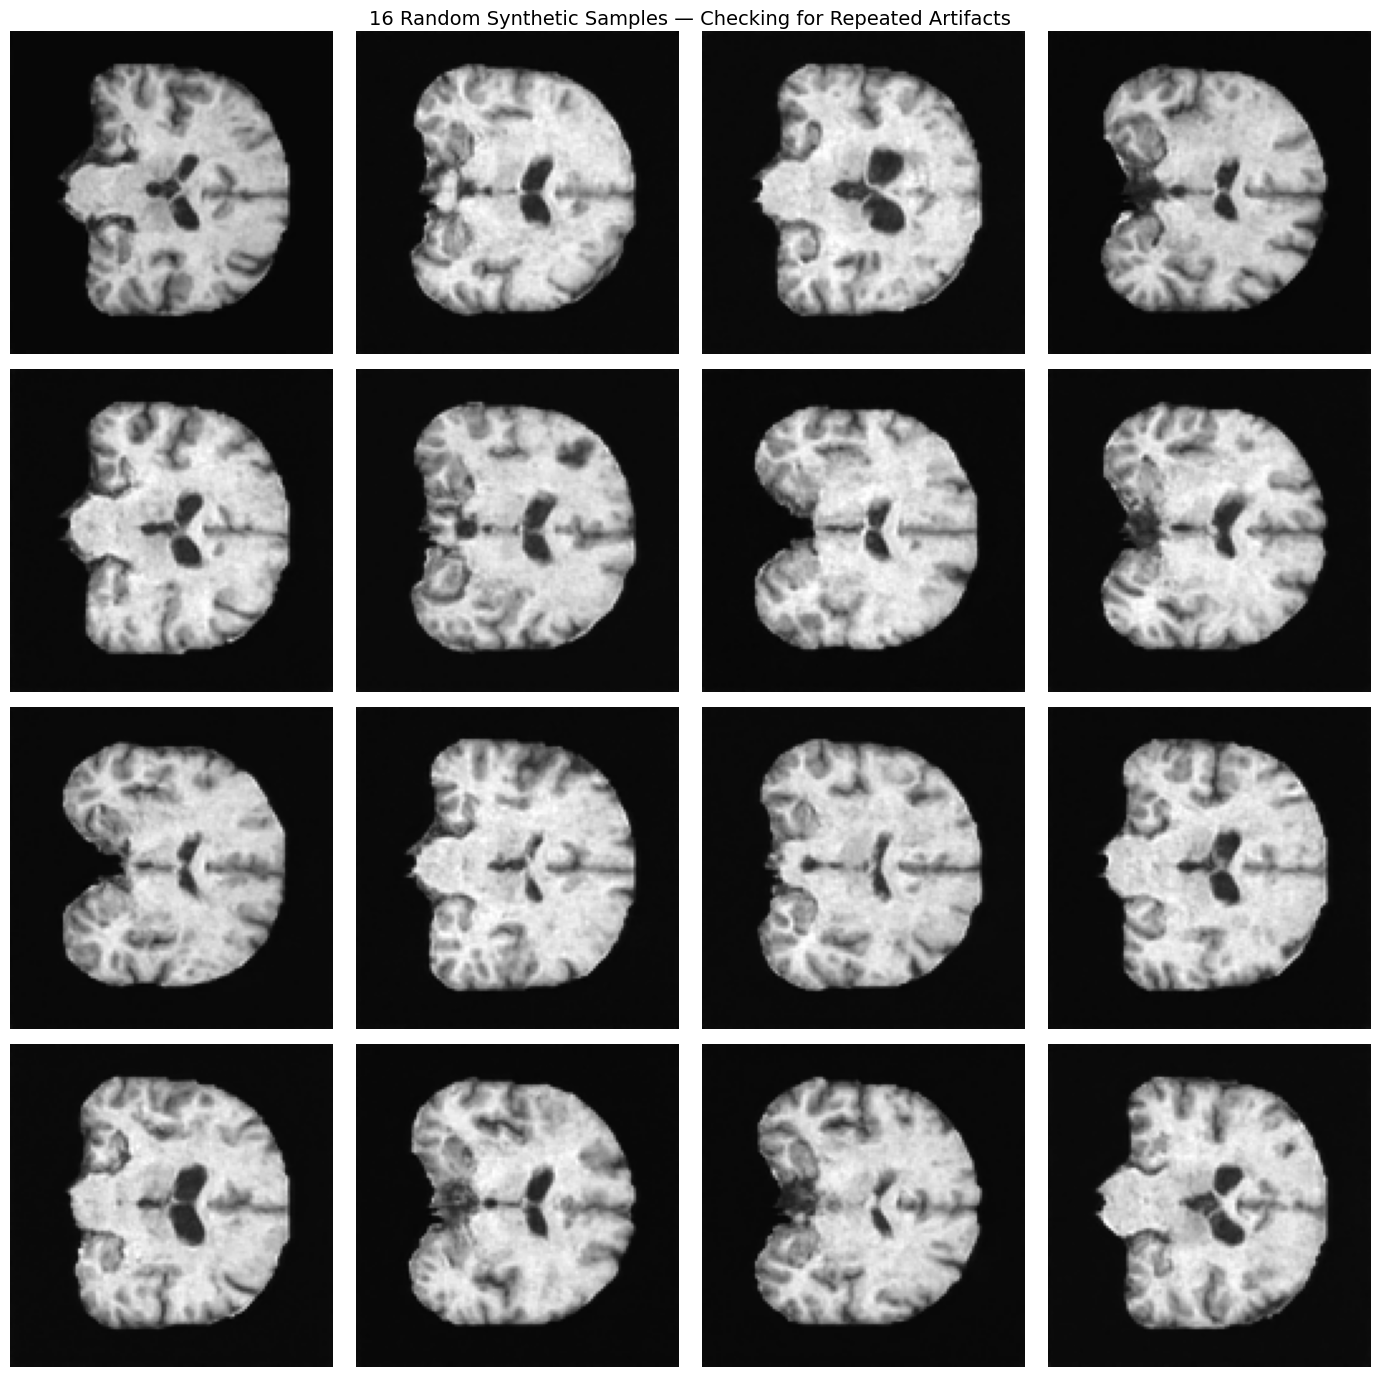

In [14]:
import matplotlib.pyplot as plt
from PIL import Image
import os

GEN_DIR = '/content/drive/MyDrive/ddpm_coronal_output/fid_generated'  # your 350 DDPM images
files = sorted(os.listdir(GEN_DIR))[:16]

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle('16 Random Synthetic Samples — Checking for Repeated Artifacts', fontsize=14)
for i, f in enumerate(files):
    img = Image.open(os.path.join(GEN_DIR, f))
    axes[i//4, i%4].imshow(img, cmap='gray')
    axes[i//4, i%4].axis('off')
plt.tight_layout()

# Save the figure to Google Drive
output_path = os.path.join('/content/drive/MyDrive/ddpm_coronal_output/', 'synthetic_samples_preview.png')
plt.savefig(output_path)
print(f"Plot saved to: {output_path}")

plt.show()